# 🛒 Retail Sales ETL, Visualization & Reporting
This notebook extends the ETL pipeline with **visualizations** and **reporting**.

Every visualization function is explained with:
- Purpose
- Usage
- Example

Perfect for beginners learning **data engineering** and **data analysis**.

# 📘 1. Create Sample CSV Files

In [1]:
import pandas as pd

# --- Sales CSV ---
sales_csv = """
sale_id,product_id,quantity,price,date
1,101,2,15.50,2024-01-01
2,103,1,45.00,2024-01-01
3,102,3,12.00,2024-01-02
4,101,1,15.50,2024-01-02
5,104,5,8.00,2024-01-03
6,103,2,45.00,2024-01-03
7,102,4,12.00,2024-01-04
8,104,3,8.00,2024-01-04
"""

with open("sales.csv", "w") as f:
    f.write(sales_csv)

# --- Product Lookup CSV ---
products_csv = """
product_id,product_name,category
101,Notebook,Stationery
102,Pen,Stationery
103,Backpack,Bags
104,Water Bottle,Accessories
"""

with open("products.csv", "w") as f:
    f.write(products_csv)

# 📘 2. Extract — Read CSV Files

In [2]:
sales_df = pd.read_csv("sales.csv")
products_df = pd.read_csv("products.csv")

sales_df, products_df

(   sale_id  product_id  quantity  price        date
 0        1         101         2   15.5  2024-01-01
 1        2         103         1   45.0  2024-01-01
 2        3         102         3   12.0  2024-01-02
 3        4         101         1   15.5  2024-01-02
 4        5         104         5    8.0  2024-01-03
 5        6         103         2   45.0  2024-01-03
 6        7         102         4   12.0  2024-01-04
 7        8         104         3    8.0  2024-01-04,
    product_id  product_name     category
 0         101      Notebook   Stationery
 1         102           Pen   Stationery
 2         103      Backpack         Bags
 3         104  Water Bottle  Accessories)

# 📘 3. Transform — Clean & Enrich Data

In [3]:
# Add total_amount
sales_df['total_amount'] = sales_df['quantity'] * sales_df['price']

# Join with product lookup
merged_df = sales_df.merge(products_df, on='product_id', how='left')

# Convert date to datetime
merged_df['date'] = pd.to_datetime(merged_df['date'])

# Sort by date
merged_df = merged_df.sort_values(by='date')

merged_df

,sale_id,product_id,quantity,price,date,total_amount,product_name,category
0,1,101,2,15.5,2024-01-01,31.0,Notebook,Stationery
1,2,103,1,45.0,2024-01-01,45.0,Backpack,Bags
2,3,102,3,12.0,2024-01-02,36.0,Pen,Stationery
3,4,101,1,15.5,2024-01-02,15.5,Notebook,Stationery
4,5,104,5,8.0,2024-01-03,40.0,Water Bottle,Accessories
5,6,103,2,45.0,2024-01-03,90.0,Backpack,Bags
6,7,102,4,12.0,2024-01-04,48.0,Pen,Stationery
7,8,104,3,8.0,2024-01-04,24.0,Water Bottle,Accessories


# 📘 4. Load — Save Final ETL Output

In [4]:
merged_df.to_csv("sales_etl_output.csv", index=False)
merged_df

,sale_id,product_id,quantity,price,date,total_amount,product_name,category
0,1,101,2,15.5,2024-01-01,31.0,Notebook,Stationery
1,2,103,1,45.0,2024-01-01,45.0,Backpack,Bags
2,3,102,3,12.0,2024-01-02,36.0,Pen,Stationery
3,4,101,1,15.5,2024-01-02,15.5,Notebook,Stationery
4,5,104,5,8.0,2024-01-03,40.0,Water Bottle,Accessories
5,6,103,2,45.0,2024-01-03,90.0,Backpack,Bags
6,7,102,4,12.0,2024-01-04,48.0,Pen,Stationery
7,8,104,3,8.0,2024-01-04,24.0,Water Bottle,Accessories


# 📊 5. Data Analysis — Summary Metrics

In [5]:
total_revenue = merged_df['total_amount'].sum()
revenue_by_category = merged_df.groupby('category')['total_amount'].sum()
top_products = merged_df.groupby('product_name')['quantity'].sum().sort_values(ascending=False)
daily_summary = merged_df.groupby('date')['total_amount'].sum()

total_revenue, revenue_by_category, top_products, daily_summary

(329.5,
 category
 Accessories     64.0
 Bags           135.0
 Stationery     130.5
 Name: total_amount, dtype: float64,
 product_name
 Water Bottle    8
 Pen             7
 Backpack        3
 Notebook        3
 Name: quantity, dtype: int64,
 date
 2024-01-01     76.0
 2024-01-02     51.5
 2024-01-03    130.0
 2024-01-04     72.0
 Name: total_amount, dtype: float64)

# 📘 6. Visualization Functions — Explanation
Below are explanations for each visualization function used.

## 🔵 `import matplotlib.pyplot as plt`
**Purpose:** Main plotting library in Python.
**Usage:** Used to create charts (line, bar, scatter).
**Example:** `plt.figure(figsize=(10,5))`

## 🔵 `import seaborn as sns`
**Purpose:** Statistical visualization library built on top of matplotlib.
**Usage:** Creates cleaner, more attractive charts.
**Example:** `sns.lineplot(x=df['date'], y=df['sales'])`

## 🔵 `sns.lineplot()`
**Purpose:** Draws a line chart.
**Usage:** `sns.lineplot(x=<x-axis>, y=<y-axis>)`
**Example:** Daily revenue trend.

## 🔵 `sns.barplot()`
**Purpose:** Draws a bar chart.
**Usage:** `sns.barplot(x=categories, y=values)`
**Example:** Revenue by category.

## 🔵 `plt.figure()`
**Purpose:** Creates a new chart canvas.
**Usage:** `plt.figure(figsize=(width,height))`

## 🔵 `plt.title()`
**Purpose:** Adds a title to the chart.
**Usage:** `plt.title('Daily Revenue')`

## 🔵 `plt.xlabel()` / `plt.ylabel()`
**Purpose:** Label the X and Y axes.
**Usage:** `plt.xlabel('Date')`, `plt.ylabel('Revenue')`

## 🔵 `plt.xticks(rotation=45)`
**Purpose:** Rotate X-axis labels for readability.
**Usage:** `plt.xticks(rotation=45)`

## 🔵 `plt.show()`
**Purpose:** Displays the chart.
**Usage:** Always call after building a chart.

## 🔵 `daily_summary.plot()`
**Purpose:** Pandas built‑in plotting.
**Usage:** `df.plot(kind='bar')`
**Example:** Daily revenue bar chart.

# 📈 7. Visualization — Matplotlib & Seaborn

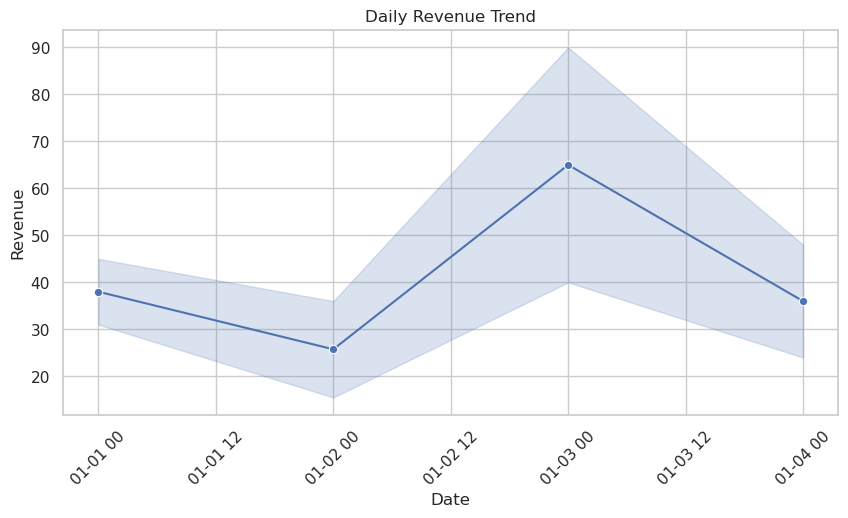

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# --- Daily Revenue Trend ---
plt.figure(figsize=(10,5))
sns.lineplot(x=merged_df['date'], y=merged_df['total_amount'], marker='o')
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

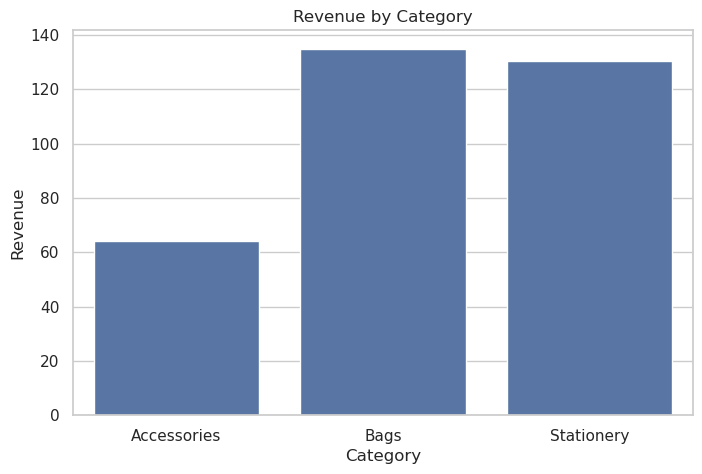

In [7]:
# --- Revenue by Category ---
plt.figure(figsize=(8,5))
sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values)
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

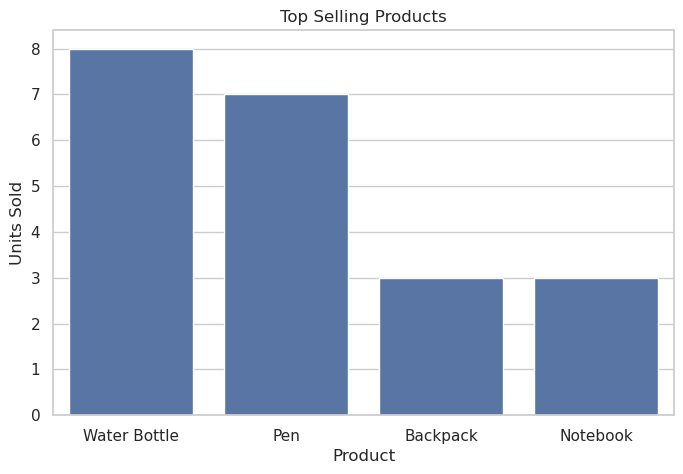

In [8]:
# --- Top Selling Products ---
plt.figure(figsize=(8,5))
sns.barplot(x=top_products.index, y=top_products.values)
plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Units Sold')
plt.show()

# 📊 8. Pandas Built‑In Reporting

<Axes: title={'center': 'Daily Revenue (Bar Chart)'}, xlabel='date'>

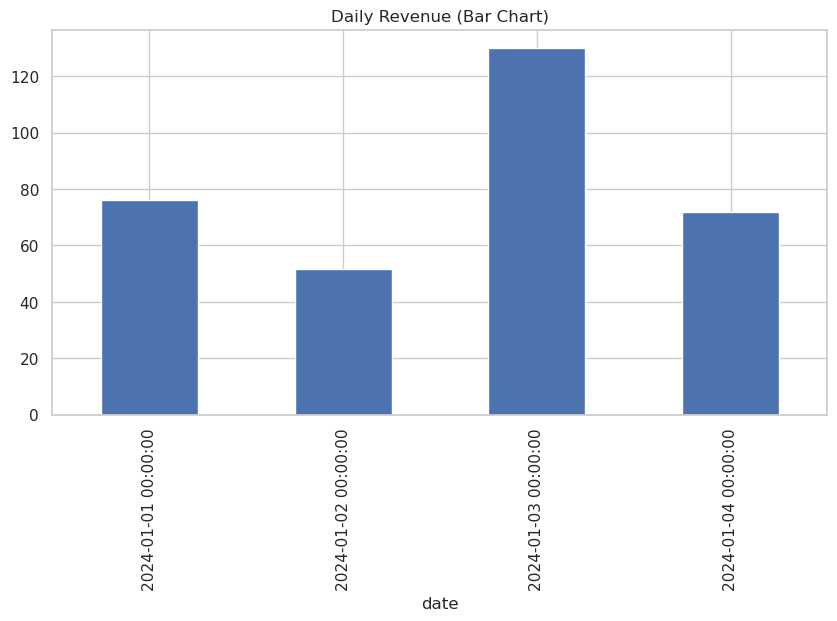

In [9]:
daily_summary.plot(kind='bar', figsize=(10,5), title='Daily Revenue (Bar Chart)')

# 🎉 What is Covered:
You now have:
- Full ETL pipeline
- Visualization functions explained
- Reporting charts
- Real‑world retail dataset

Perfect for **data engineering**, **ETL**, and **analytics** practice.